# Regression-geçmiş verilerden öğrenip geleceği tahmin etme

iki veya daha fazla değişken arasındaki ilişkiyi analiz etmek için kullanılan yönteme regressipn denir. Bugün regression modellerini denrinlemesine öğreneceğiz. Araba fiyatlarını tahmin eden bir makine öğrenme algoritması geliştireceğiz. %85 oranında başarıyı hedefliyoruz.

# Data dosyasını okuma

In [4]:
import pandas as pd
import sqlite3 #veri tabanindan veri almak
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
conn=sqlite3.connect('cars.db')

In [6]:
df=pd.read_sql_query('select * from cars', conn)

In [7]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832.0,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [9]:
pip install xlrd 

Note: you may need to restart the kernel to use updated packages.


In [10]:
df=pd.read_excel('cars.xls')

In [11]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [13]:
df.to_json('cars.json') #json javascript object notation web siteleri arasında veri transferi için kullanılır.

In [19]:
df=pd.read_json('cars.json')

In [20]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [30]:
df = pd.read_clipboard(sep='\t')

In [31]:
df

,Company,Contact,Country
0,Alfreds Futterkiste,Maria Anders,Germany
1,Centro comercial Moctezuma,Francisco Chang,Mexico
2,Ernst Handel,Roland Mendel,Austria
3,Island Trading,Helen Bennett,UK
4,Laughing Bacchus Winecellars,Yoshi Tannamuri,Canada
5,Magazzini Alimentari Riuniti,Giovanni Rovelli,Italy


# EDA Exploratory Data Analysis

In [33]:
df.head()

,Company,Contact,Country
0,Alfreds Futterkiste,Maria Anders,Germany
1,Centro comercial Moctezuma,Francisco Chang,Mexico
2,Ernst Handel,Roland Mendel,Austria
3,Island Trading,Helen Bennett,UK
4,Laughing Bacchus Winecellars,Yoshi Tannamuri,Canada


In [34]:
df.tail()

,Company,Contact,Country
1,Centro comercial Moctezuma,Francisco Chang,Mexico
2,Ernst Handel,Roland Mendel,Austria
3,Island Trading,Helen Bennett,UK
4,Laughing Bacchus Winecellars,Yoshi Tannamuri,Canada
5,Magazzini Alimentari Riuniti,Giovanni Rovelli,Italy


In [35]:
df.sample()

,Company,Contact,Country
2,Ernst Handel,Roland Mendel,Austria


In [36]:
df.shape

(6, 3)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Company  6 non-null      object
 1   Contact  6 non-null      object
 2   Country  6 non-null      object
dtypes: object(3)
memory usage: 276.0+ bytes


In [38]:
df.isnull().sum()

Company    0
Contact    0
Country    0
dtype: int64

In [39]:
df.describe()

,Company,Contact,Country
count,6,6,6
unique,6,6,6
top,Alfreds Futterkiste,Maria Anders,Germany
freq,1,1,1


In [40]:
df=pd.read_excel('cars.xls')

In [41]:
df.describe()

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
count,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000
mean,21343.143767,19831.934080,5.268657,3.037313,3.527363,0.752488,0.679104,0.723881
std,9884.852801,8196.319707,1.387531,1.105562,0.850169,0.431836,0.467111,0.447355
min,8638.930895,266.000000,4.000000,1.600000,2.000000,0.000000,0.000000,0.000000
25%,14273.073870,14623.500000,4.000000,2.200000,4.000000,1.000000,0.000000,0.000000
50%,18024.995019,20913.500000,6.000000,2.800000,4.000000,1.000000,1.000000,1.000000
75%,26717.316636,25213.000000,6.000000,3.800000,4.000000,1.000000,1.000000,1.000000
max,70755.466717,50387.000000,8.000000,6.000000,4.000000,1.000000,1.000000,1.000000


In [42]:
df.corr(numeric_only=True)

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
Price,1.000000,-0.143051,0.569086,0.558146,-0.138750,0.430851,-0.124348,0.157197
Mileage,-0.143051,1.000000,-0.029461,-0.018641,-0.016944,0.025037,-0.026146,0.001005
Cylinder,0.569086,-0.029461,1.000000,0.957897,0.002206,0.354285,-0.089704,0.075520
Liter,0.558146,-0.018641,0.957897,1.000000,-0.079259,0.377509,-0.065527,0.087332
Doors,-0.138750,-0.016944,0.002206,-0.079259,1.000000,-0.047674,-0.062530,-0.061969
Cruise,0.430851,0.025037,0.354285,0.377509,-0.047674,1.000000,-0.091730,-0.070573
Sound,-0.124348,-0.026146,-0.089704,-0.065527,-0.062530,-0.091730,1.000000,0.165444
Leather,0.157197,0.001005,0.075520,0.087332,-0.061969,-0.070573,0.165444,1.000000


<Axes: >

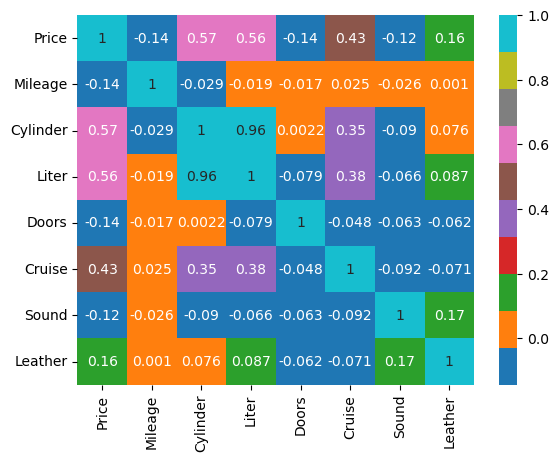

In [44]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='tab10')

In [45]:
df['Make'].unique()

array(['Buick', 'Cadillac', 'Chevrolet', 'Pontiac', 'SAAB', 'Saturn'],
      dtype=object)

In [49]:
df['Make'].value_counts(normalize=True)

Make
Chevrolet    0.398010
Pontiac      0.186567
SAAB         0.141791
Buick        0.099502
Cadillac     0.099502
Saturn       0.074627
Name: proportion, dtype: float64

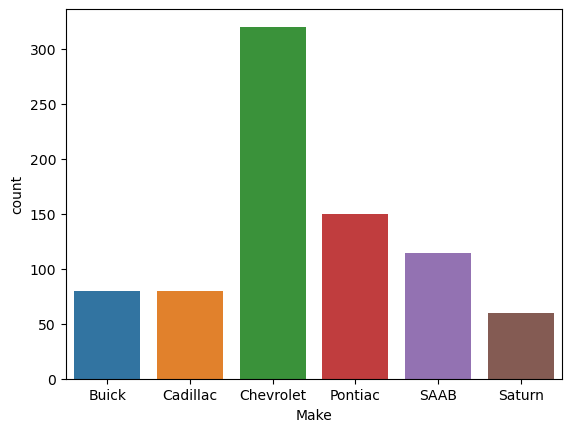

In [51]:
sns.countplot(x=df['Make'], hue=df['Make']);

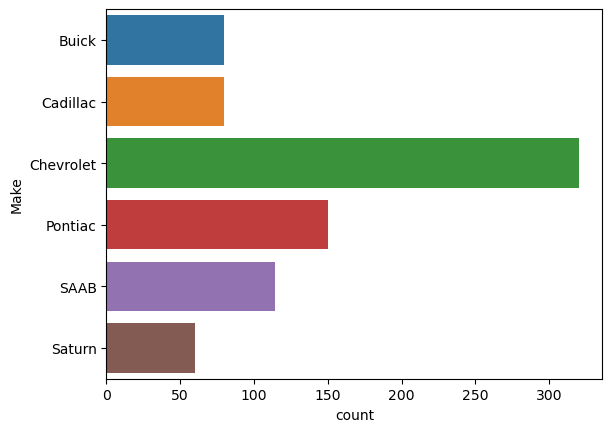

In [52]:
sns.countplot(y=df['Make'], hue=df['Make']);

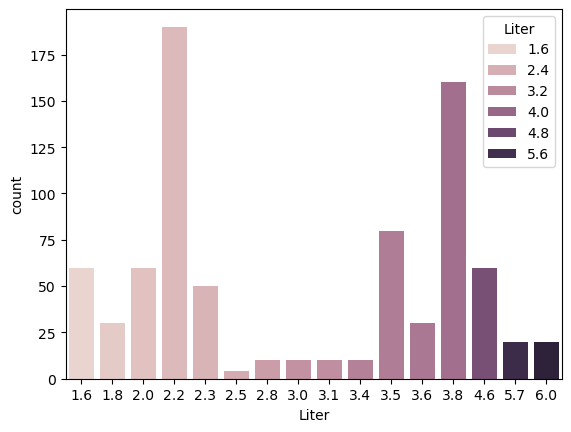

In [53]:
sns.countplot(x=df['Liter'], hue=df['Liter']);

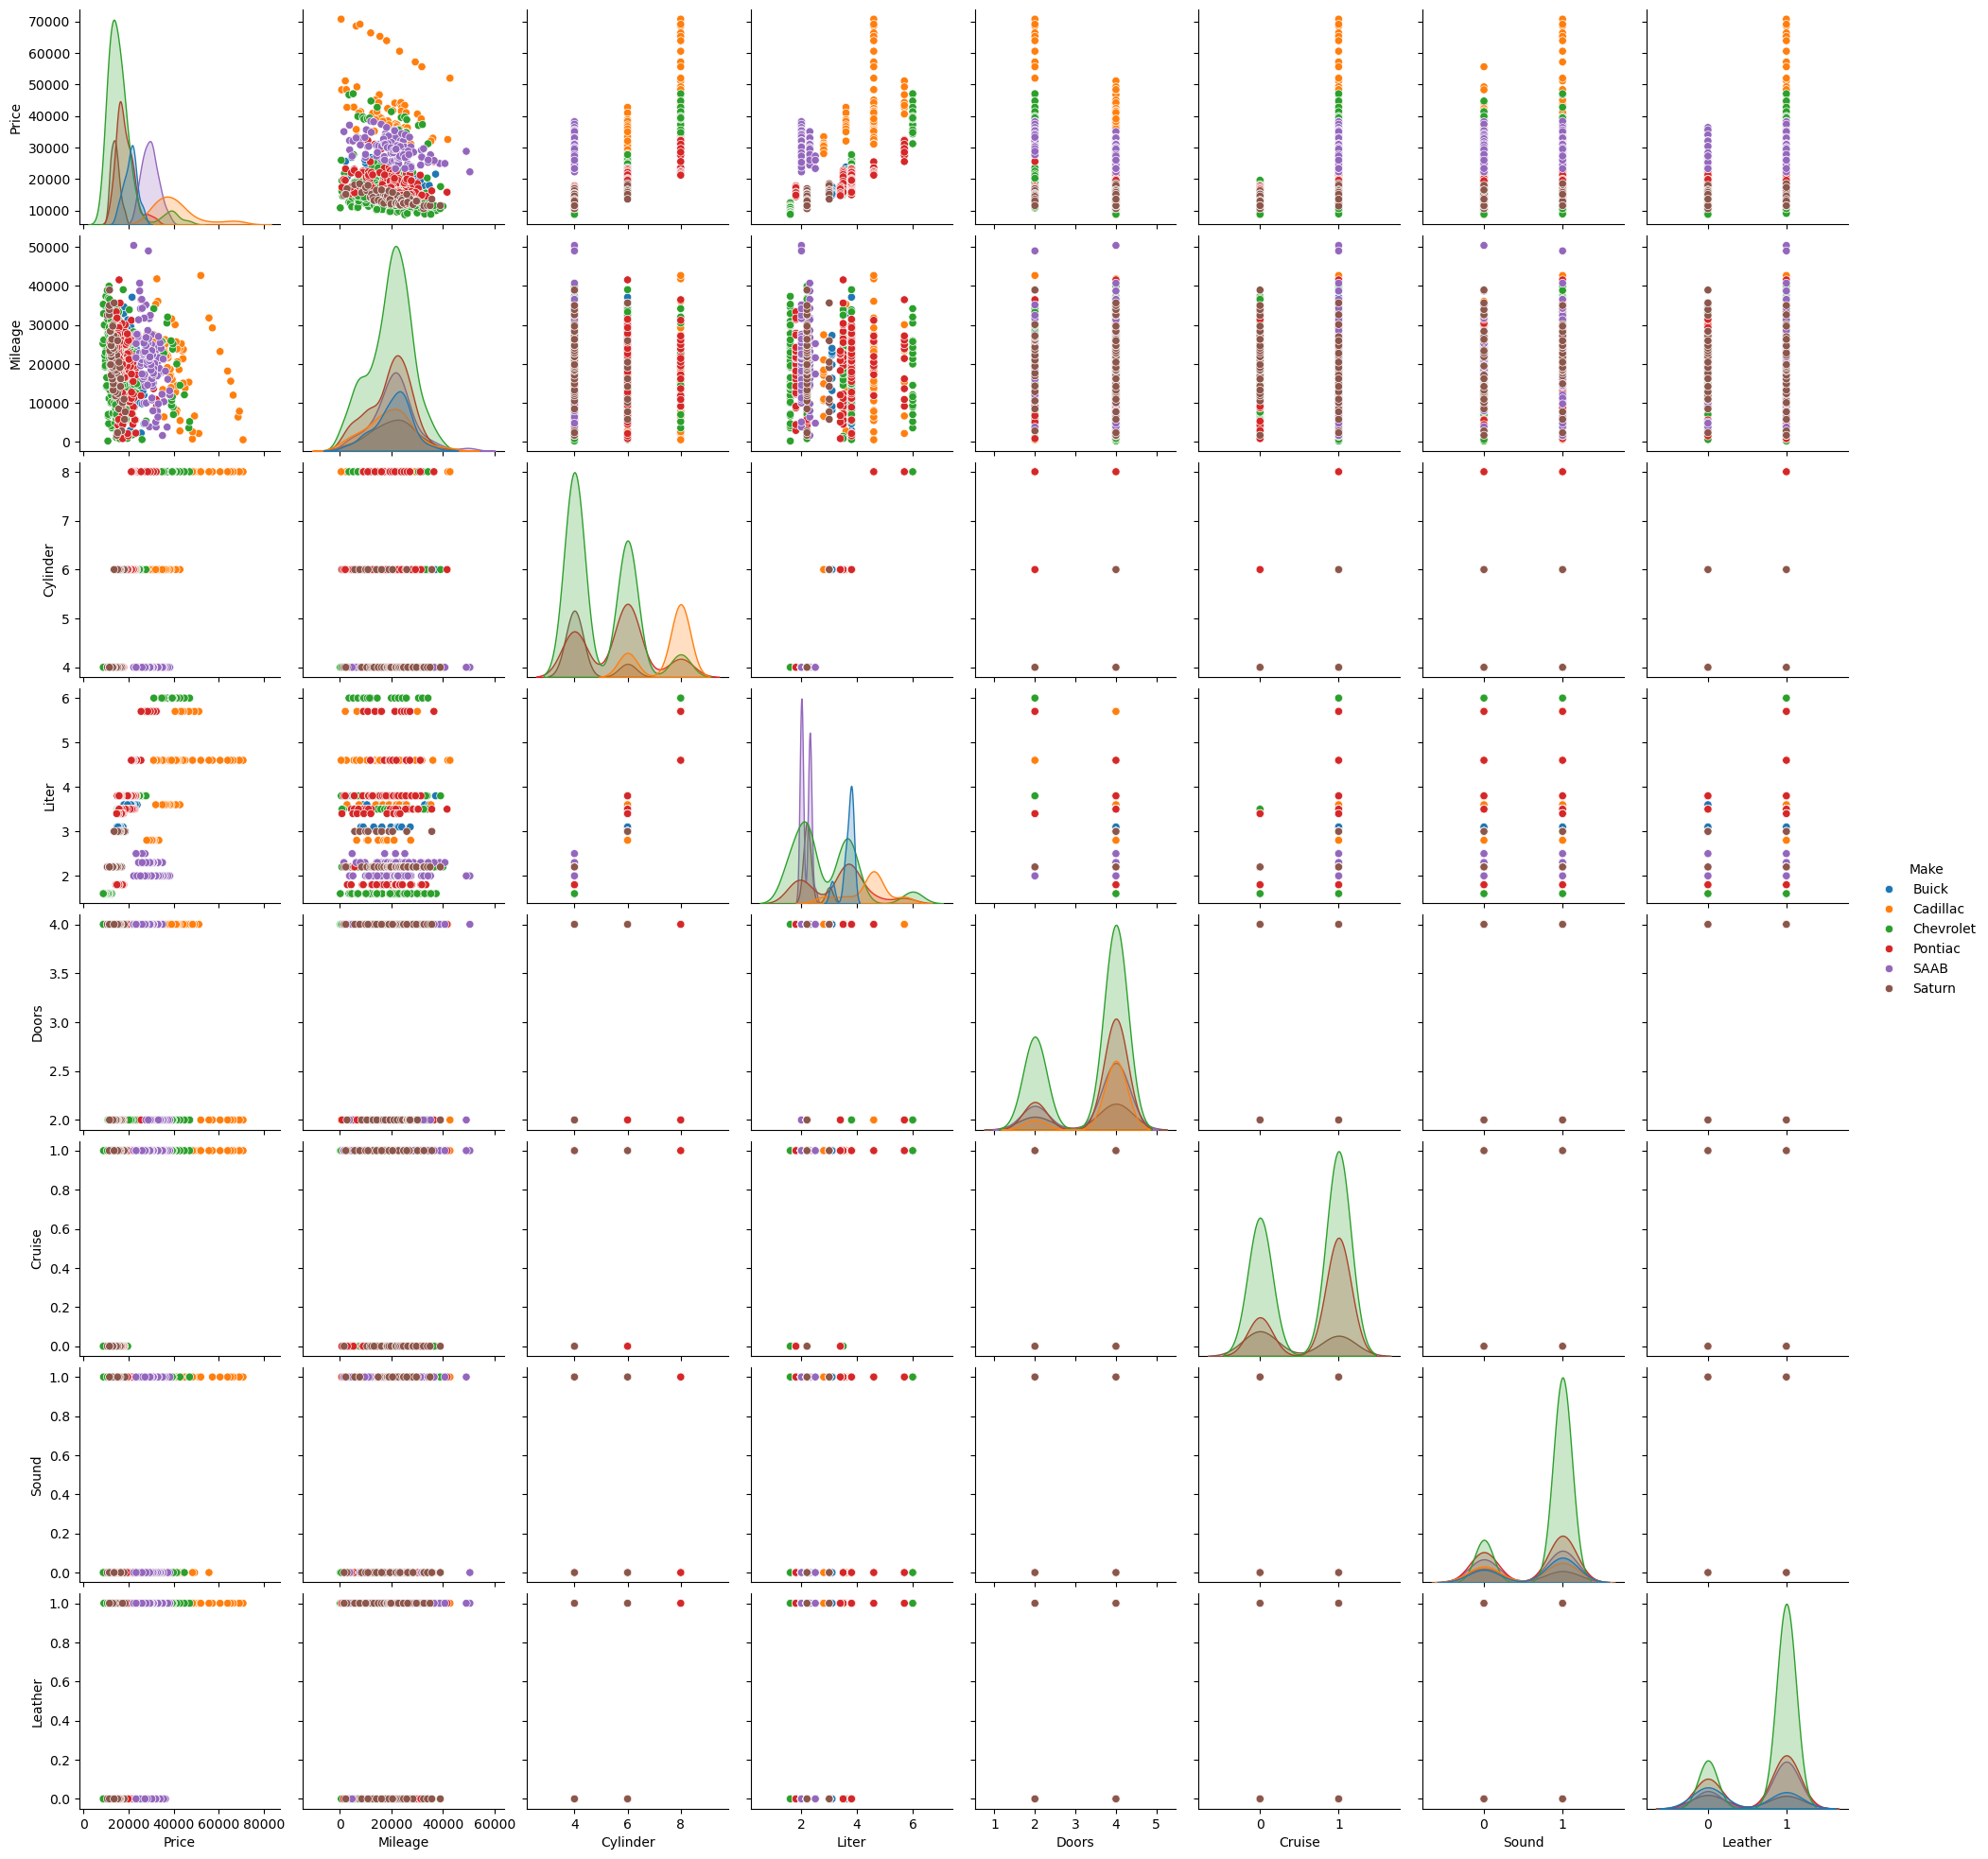

In [55]:
sns.pairplot(df, hue='Make')

<Axes: xlabel='Mileage', ylabel='Price'>

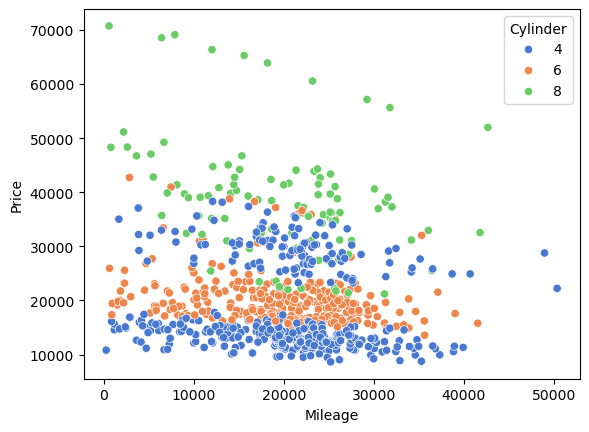

In [58]:
sns.scatterplot(x=df['Mileage'],y=df['Price'],hue=df['Cylinder'], palette='muted')

# P VALUE HESAPLAMA

#### sIFIR hİPOTEZİ, HO= ARABANIN ÜZERİNDEKİ KM İLE FİYAT ARASINDA BAĞ YOKTUR. HA=ARABANIN ÜZERİNDEKİ KM FİYATINI ETKİLER

In [66]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [67]:

from scipy.stats import ttest_ind

In [70]:
t,p=ttest_ind(df['Price'],df['Mileage'])

In [71]:
p

np.float64(0.0008662338227446262)

In [72]:
p<0.05

np.True_

In [73]:
# Sonuc: arabanın fiyatı ile km arasında bir bağ vardır. Tesadüf ile açıklanamaz.

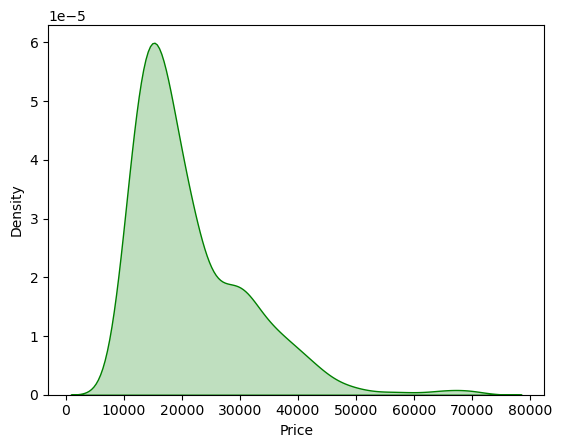

In [75]:
sns.kdeplot(x=df['Price'], fill=True, color='green'); #outlier boxplot

<Axes: >

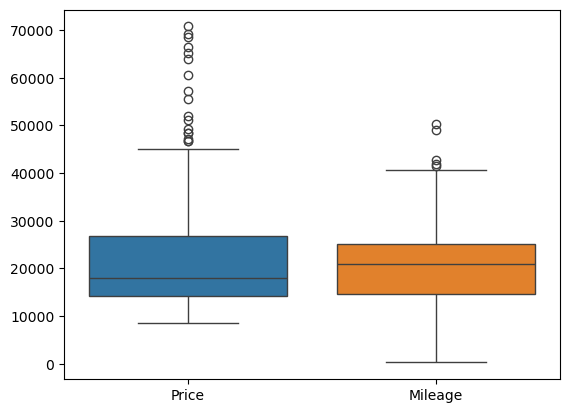

In [77]:
sns.boxplot([df['Price'], df['Mileage']])

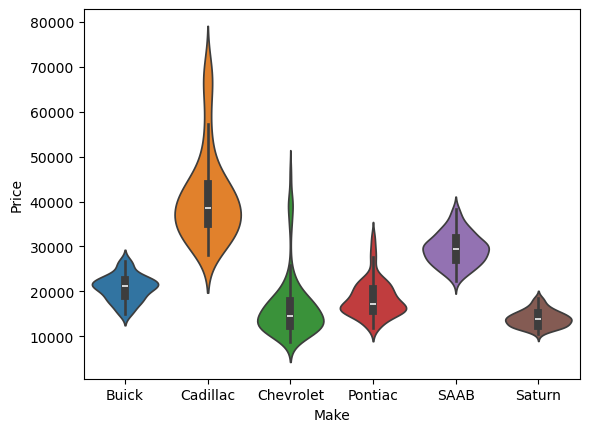

In [79]:
sns.violinplot(x='Make', y='Price', data=df, hue='Make');

In [80]:
import plotly.express as px

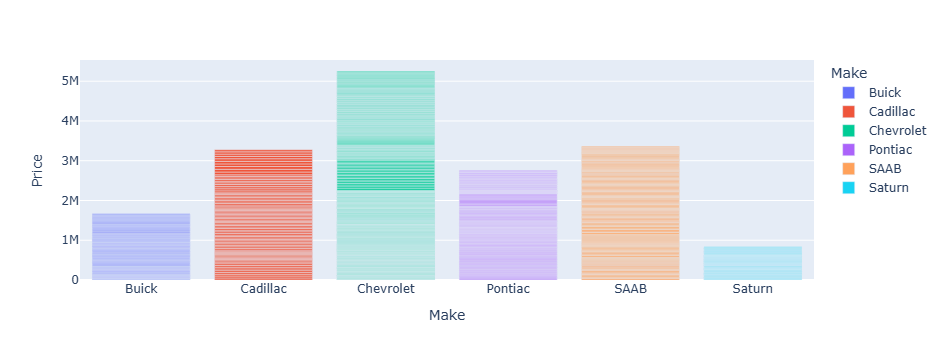

In [82]:
px.bar(df, x='Make', y='Price', color='Make')

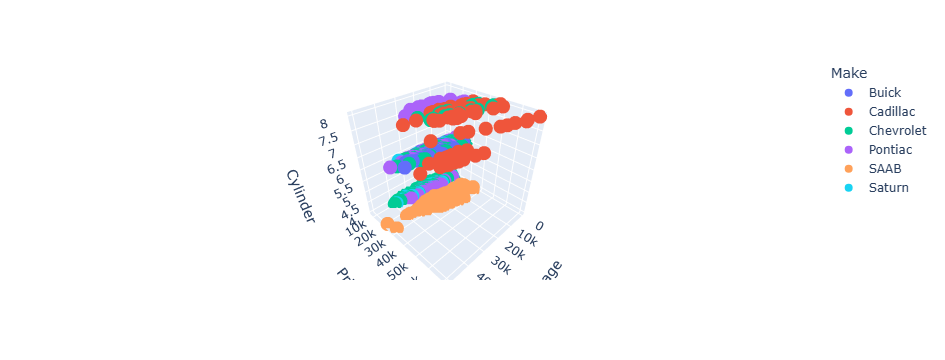

In [84]:
px.scatter_3d(df, x='Mileage',y='Price', color='Make', z='Cylinder' )

In [86]:
df.corr(numeric_only=True)

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
Price,1.000000,-0.143051,0.569086,0.558146,-0.138750,0.430851,-0.124348,0.157197
Mileage,-0.143051,1.000000,-0.029461,-0.018641,-0.016944,0.025037,-0.026146,0.001005
Cylinder,0.569086,-0.029461,1.000000,0.957897,0.002206,0.354285,-0.089704,0.075520
Liter,0.558146,-0.018641,0.957897,1.000000,-0.079259,0.377509,-0.065527,0.087332
Doors,-0.138750,-0.016944,0.002206,-0.079259,1.000000,-0.047674,-0.062530,-0.061969
Cruise,0.430851,0.025037,0.354285,0.377509,-0.047674,1.000000,-0.091730,-0.070573
Sound,-0.124348,-0.026146,-0.089704,-0.065527,-0.062530,-0.091730,1.000000,0.165444
Leather,0.157197,0.001005,0.075520,0.087332,-0.061969,-0.070573,0.165444,1.000000


In [87]:
abs(df.corr(numeric_only=True))['Price'].sort_values(ascending=False)

Price       1.000000
Cylinder    0.569086
Liter       0.558146
Cruise      0.430851
Leather     0.157197
Mileage     0.143051
Doors       0.138750
Sound       0.124348
Name: Price, dtype: float64

In [90]:
x=df[['Mileage','Cylinder','Liter','Cruise']]
y=df[['Price']]

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42,test_size=0.20)

In [94]:
x_train.shape

(643, 4)

In [95]:
x_test.shape

(161, 4)

In [97]:
161/ (643+161)

0.20024875621890548

In [99]:
from sklearn.linear_model import LinearRegression

In [100]:
lr=LinearRegression()

In [101]:
model=lr.fit(x_train,y_train)

In [103]:
tahmin=lr.predict(x_test)

In [104]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [105]:
r2_score(y_test,tahmin)

0.30711149069980004

In [108]:
mean_squared_error(y_test,tahmin)**.5

7413.255792158802

In [110]:
x=df[['Mileage','Cylinder','Liter','Cruise','Make','Model','Trim']]
y=df[['Price']]

In [111]:
x=pd.get_dummies(x,drop_first=True)

In [112]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42,test_size=0.20)

In [113]:
x.head()

,Mileage,Cylinder,Liter,Cruise,Make_Cadillac,Make_Chevrolet,Make_Pontiac,Make_SAAB,Make_Saturn,Model_9_3,...,Trim_Quad Coupe 2D,Trim_SE Sedan 4D,Trim_SLE Sedan 4D,Trim_SS Coupe 2D,Trim_SS Sedan 4D,Trim_SVM Hatchback 4D,Trim_SVM Sedan 4D,Trim_Sedan 4D,Trim_Special Ed Ultra 4D,Trim_Sportwagon 4D
0,8221,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,9135,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,13196,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,16342,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,19832,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [114]:
model=lr.fit(x_train,y_train)


In [115]:
tahmin=lr.predict(x_test)

In [116]:
r2_score(y_test,tahmin)

0.9911885467725752

In [117]:
mean_squared_error(y_test,tahmin)**.5

835.9899877500748

In [120]:
karsilastirma=pd.DataFrame()

In [121]:
karsilastirma['Gercek Fiyat']=y_test
karsilastirma['Tahmin']=tahmin

In [122]:
karsilastirma.head()

,Gercek Fiyat,Tahmin
192,11302.902985,11931.572448
717,29114.544506,29589.064196
168,10777.052537,9679.382185
522,20677.593819,20806.642631
536,15253.868566,14979.560535


In [123]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [124]:
R=Ridge()
L=Lasso()
E=ElasticNet()

In [125]:
R.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [126]:
rtahmin=R.predict(x_test)

In [127]:
r2_score(y_test,tahmin)

0.9911885467725752

In [128]:
L.fit(x_train,y_train)

C:\Anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.458e+08, tolerance: 6.560e+06



,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [130]:
ltahmin=L.predict(x_test)

In [ ]:
l

In [131]:
r2_score(y_test,ltahmin)

0.9913274182884081

In [132]:
model.coef_

array([[-1.87571841e-01,  1.36860561e+03,  3.08314289e+03,
         7.84875188e+01,  1.15176391e+04, -2.48135940e+03,
        -2.89930092e+03,  6.36955149e+03, -2.10392446e+03,
         4.12852724e+03,  6.05231464e+03,  6.63055612e+03,
         7.21257302e+03, -7.45789358e+02, -3.13507284e+03,
         1.85966337e+03, -1.27472619e+03, -3.00730126e+02,
        -4.73165605e+03,  1.22437809e+03,  6.90594323e+02,
         6.35817207e+03, -6.59630401e+03,  2.54379654e+02,
         9.14792713e+02, -1.21055437e+03, -3.26414168e+03,
        -2.70201960e+03,  1.07784144e+02, -2.21170860e+03,
        -2.48153670e+03, -3.44518392e+03, -3.09949698e+03,
        -3.90646783e+03,  2.55770818e+02,  3.88996075e+03,
         3.23561220e+03,  3.20892578e+02,  3.22040303e+03,
         1.04034330e+04,  3.05921890e+03, -3.43187911e+03,
        -2.01040581e+03,  6.14896102e+03, -7.46102144e+02,
        -1.46134873e+01, -1.94969865e+03, -6.29582087e+02,
         9.77440324e+01,  2.89107027e+03, -2.24546993e+0

In [133]:
fi=pd.DataFrame({'Feature':x_train.columns,'Coef':model.coef_[0]})

In [134]:
fi

,Feature,Coef
0,Mileage,-0.187572
1,Cylinder,1368.605609
2,Liter,3083.142889
3,Cruise,78.487519
4,Make_Cadillac,11517.639143
...,...,...
81,Trim_SVM Hatchback 4D,-3357.779669
82,Trim_SVM Sedan 4D,-1996.070103
83,Trim_Sedan 4D,-2356.053212
84,Trim_Special Ed Ultra 4D,-575.046151


In [135]:
plt.figure(figsize=(6,20))

<Figure size 600x2000 with 0 Axes>

<Figure size 600x2000 with 0 Axes>

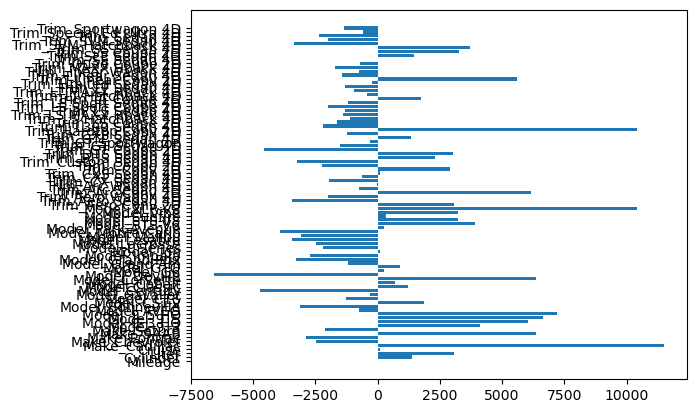

In [138]:
fi=plt.barh(fi['Feature'],fi['Coef'])

In [139]:
# modelin basarili olmasi icin r2_score>0.85, rmse dusuk olmali

In [140]:
residuals=y_test-tahmin

<Axes: xlabel='Price', ylabel='Density'>

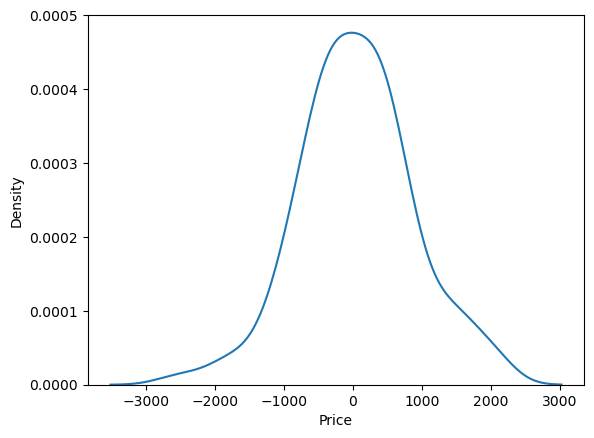

In [142]:
sns.kdeplot(x=residuals['Price'])

In [143]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [144]:
from yellowbrick.regressor import ResidualsPlot

C:\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



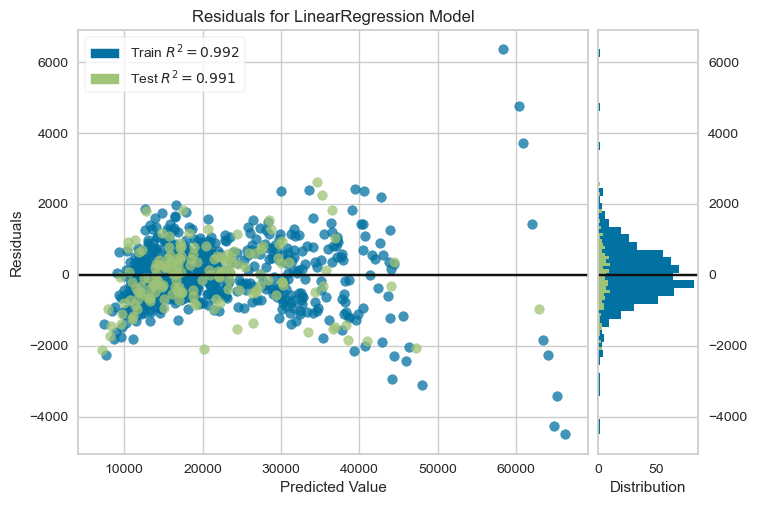

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [146]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()

In [147]:
# datayi normalize etmek

<img src=https://94fa3c88.delivery.rocketcdn.me/en/files/2020/12/illu_normali_blog-49-1024x562.png>

In [150]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [151]:
from sklearn.preprocessing import MinMaxScaler

In [152]:
x=MinMaxScaler().fit_transform(x)

In [153]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42,test_size=0.20)

In [154]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [155]:
tahmin=lr.predict(x_test)

In [157]:
r2_score(y_test,tahmin)

0.9911885467725908

In [159]:
from sklearn.tree import DecisionTreeRegressor

In [160]:
dt=DecisionTreeRegressor()

In [161]:
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [162]:
dtahmin=dt.predict(x_test)

In [164]:
r2_score(y_test,dtahmin)

0.9784898172957434

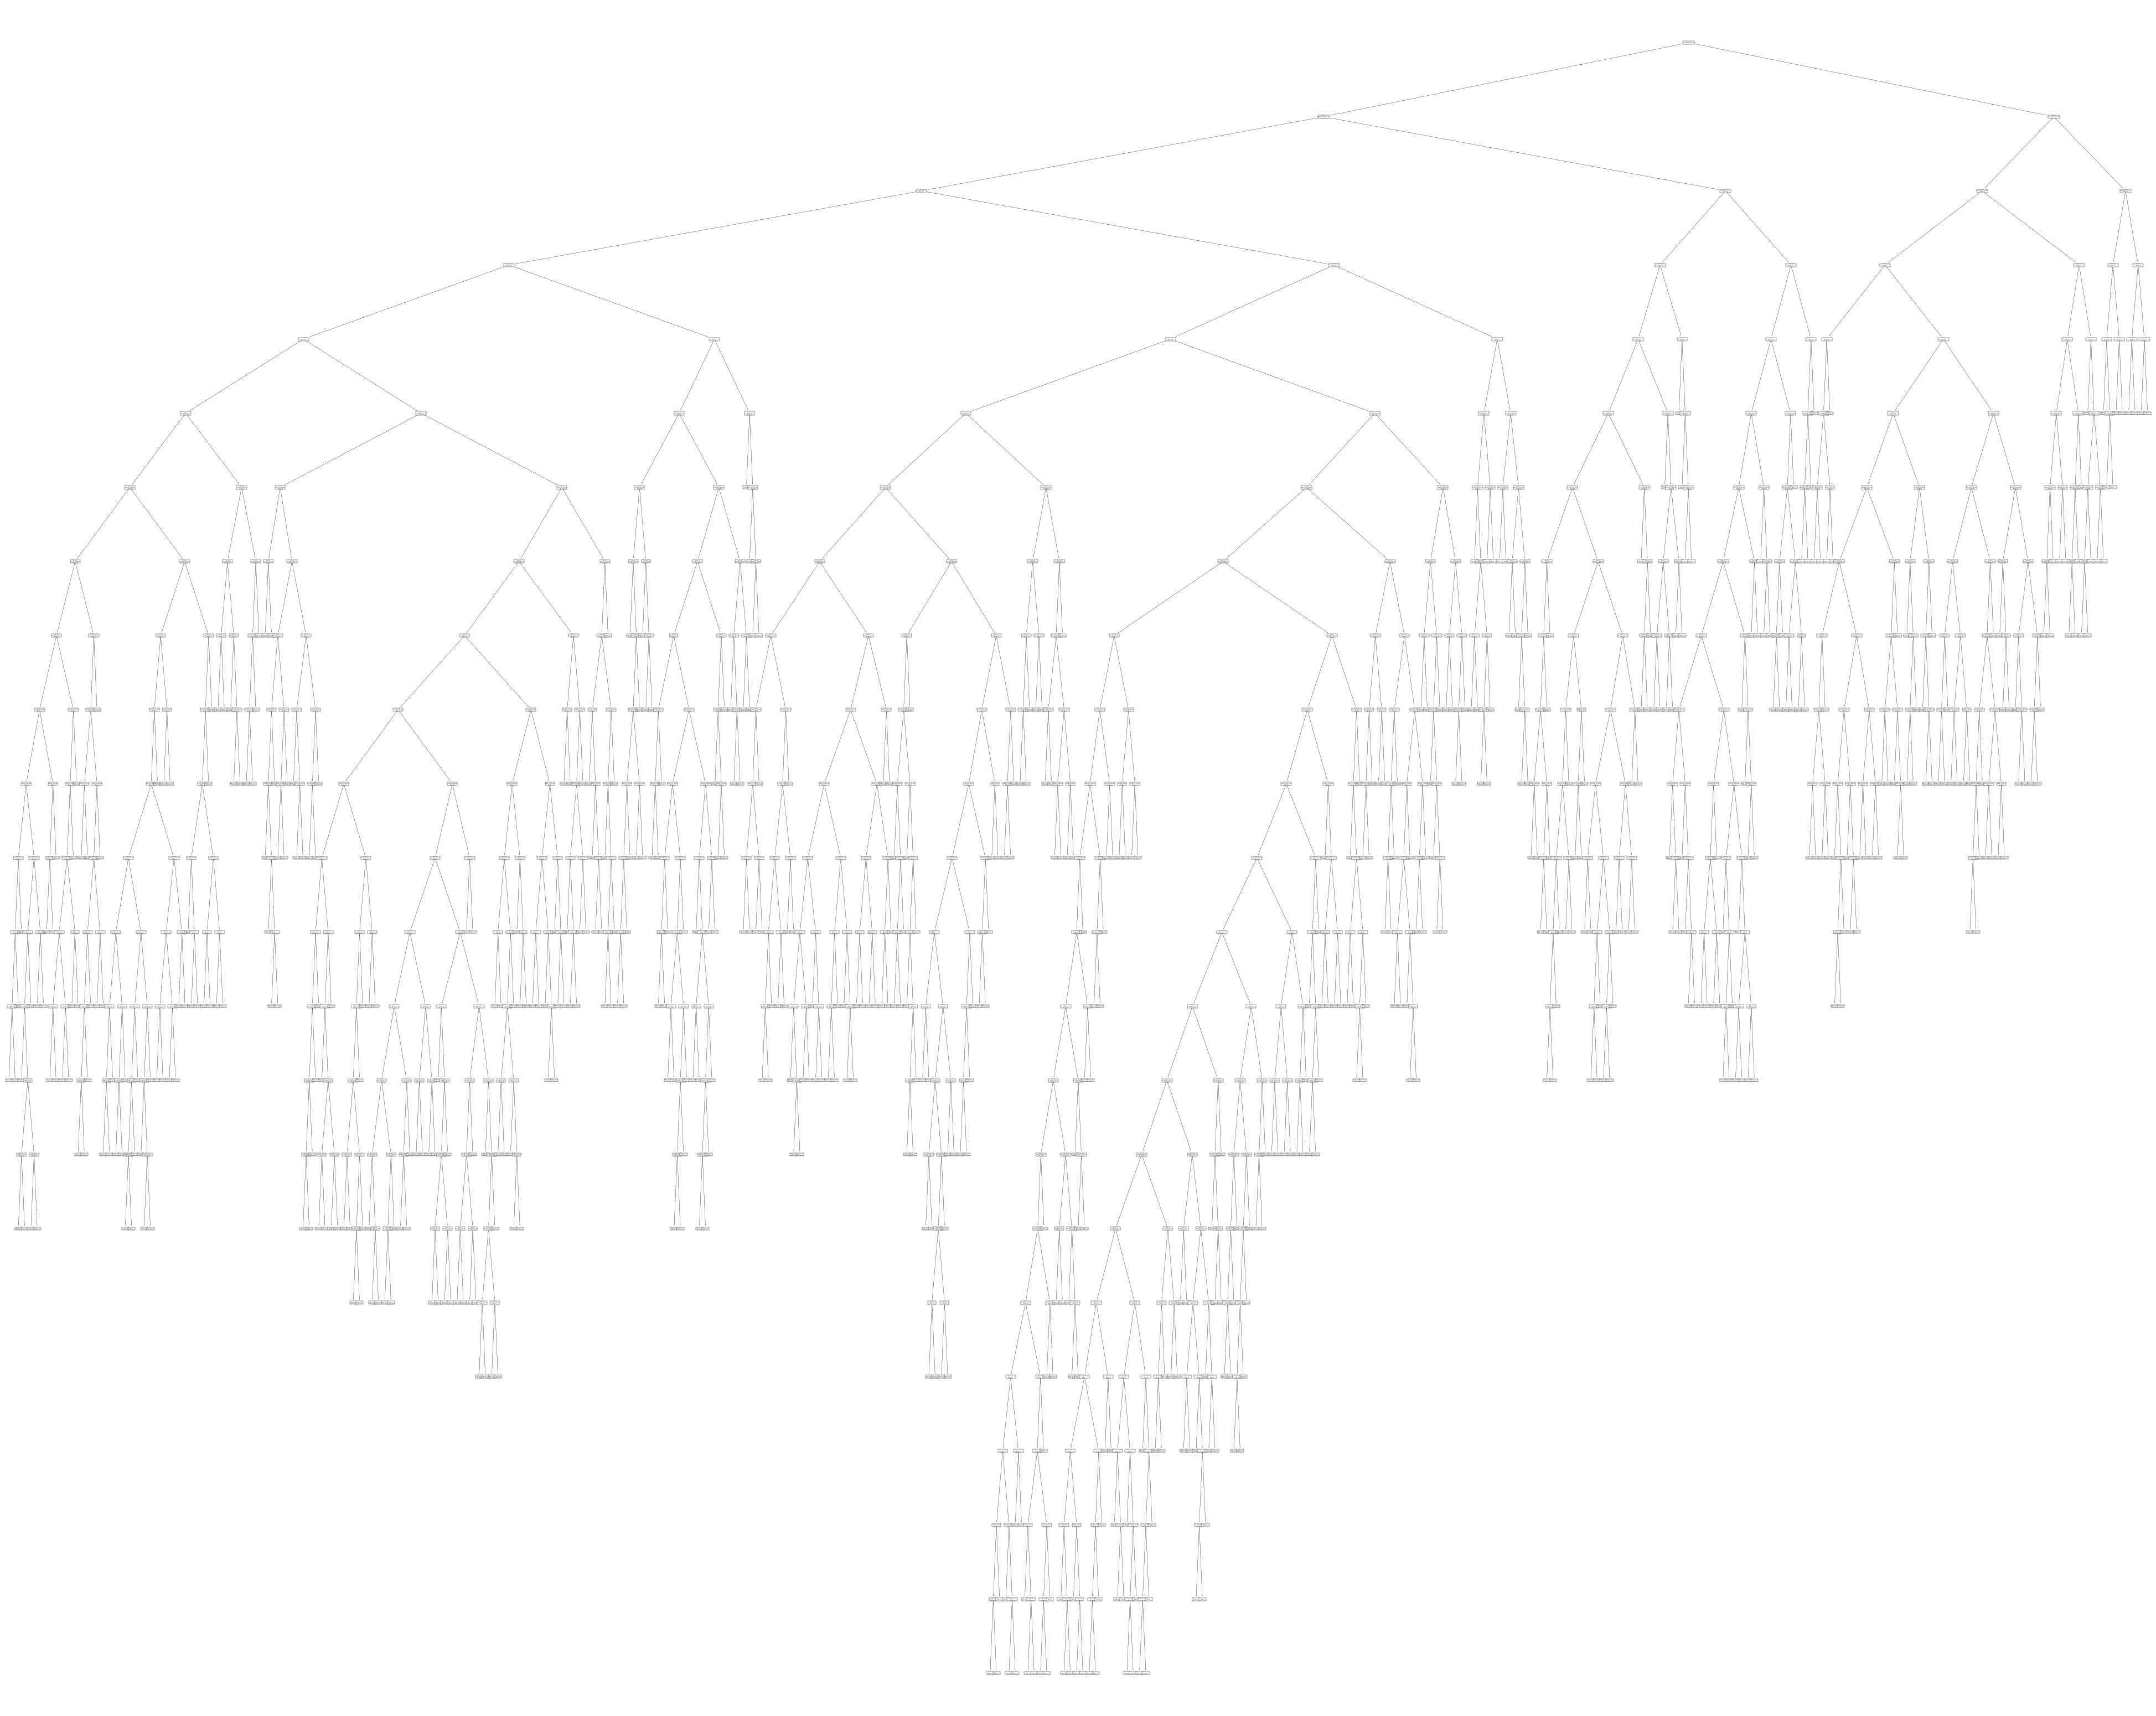

In [169]:
from sklearn.tree import plot_tree
plt.figure(figsize=(50,40))
plot_tree(dt);

In [174]:
from sklearn.ensemble import ExtraTreesRegressor

In [179]:
ET=ExtraTreesRegressor()

In [180]:
ET.fit(x_train, y_train)

C:\Anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [181]:
ettahmin=ET.predict(x_test) 

In [188]:
r2_score(y_test,ettahmin)

0.9939015366808144

In [189]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [195]:
def algo_test(x, y, test_size=0.2, random_state=42, plot=True):

    # -----------------------------
    # IMPORTS
    # -----------------------------
    import warnings
    warnings.filterwarnings("ignore")

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score, mean_squared_error

    # Linear / Regularized
    from sklearn.linear_model import (
        LinearRegression, Ridge, Lasso, ElasticNet,
        SGDRegressor, HuberRegressor, RANSACRegressor,
        BayesianRidge, OrthogonalMatchingPursuit
    )

    # Tree & Ensemble
    from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
    from sklearn.ensemble import (
        RandomForestRegressor,
        GradientBoostingRegressor,
        HistGradientBoostingRegressor,
        AdaBoostRegressor
    )

    # Other models
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.svm import SVR, NuSVR
    from sklearn.kernel_ridge import KernelRidge
    from sklearn.neural_network import MLPRegressor

    # -----------------------------
    # TRAIN TEST SPLIT
    # -----------------------------
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=test_size, random_state=random_state
    )

    # -----------------------------
    # MODELLER
    # -----------------------------
    models = [
        LinearRegression(),
        Ridge(),
        Lasso(),
        ElasticNet(),
        SGDRegressor(max_iter=1000, tol=1e-3),
        HuberRegressor(),
        RANSACRegressor(),
        BayesianRidge(),
        OrthogonalMatchingPursuit(),
        ExtraTreeRegressor(),
        DecisionTreeRegressor(),
        RandomForestRegressor(),
        GradientBoostingRegressor(),
        HistGradientBoostingRegressor(),
        AdaBoostRegressor(),
        KNeighborsRegressor(),
        SVR(),
        NuSVR(),
        KernelRidge(),
        MLPRegressor(max_iter=500)
    ]

    model_names = [
        "Linear", "Ridge", "Lasso", "ElasticNet", "SGD",
        "Huber", "RANSAC", "BayesianRidge", "OMP",
        "ExtraTree", "DecisionTree", "RandomForest",
        "GradientBoosting", "HistGradientBoosting",
        "AdaBoost", "KNN", "SVR", "NuSVR",
        "KernelRidge", "MLP"
    ]

    # -----------------------------
    # EĞİTİM & METRİKLER
    # -----------------------------
    results = []

    for model, name in zip(models, model_names):
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append([name, r2, rmse])

    result_df = pd.DataFrame(
        results, columns=["Model", "R2", "RMSE"]
    ).sort_values(by="R2", ascending=False)

    # -----------------------------
    # GRAFİKLER (OPSİYONEL)
    # -----------------------------
    if plot:
        # RMSE BARPLOT
        plt.figure(figsize=(12,5))
        sns.barplot(data=result_df, x="Model", y="RMSE", palette="magma")
        plt.title("RMSE Comparison (Lower is Better)")
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.show()

        # RMSE vs R2 SCATTER
        plt.figure(figsize=(10,6))
        sns.scatterplot(
            data=result_df,
            x="RMSE",
            y="R2",
            hue="Model",
            s=120
        )

        for _, row in result_df.iterrows():
            plt.text(row["RMSE"], row["R2"], row["Model"], fontsize=8)

        plt.title("Regression Model Trade-off: RMSE vs R2")
        plt.xlabel("RMSE (Lower is Better)")
        plt.ylabel("R2 (Higher is Better)")
        plt.grid(alpha=0.3)
        plt.show()

    # -----------------------------
    # ÇIKTI
    # -----------------------------
    return result_df


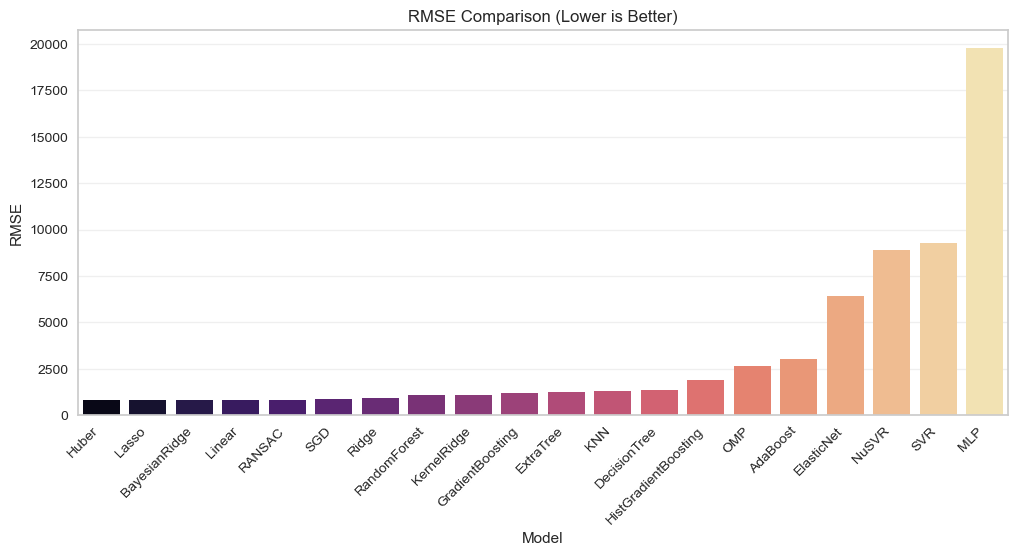

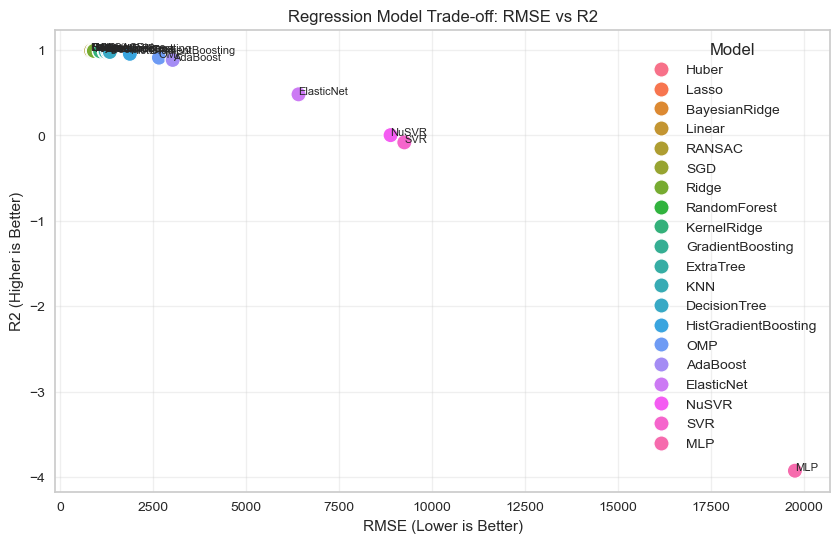

In [196]:
algo_test(x,y);

bu projede araba fiyatlarını %99.5 doğrulukla tahmin eden bir makine öğrenmesi regression modeli geliştirdik. En iyi model Huber olarak görünüyor. 

In [198]:
pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
    --------------------------------------- 1.6/102.4 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 3.1/102.4 MB 8.5 MB/s eta 0:00:12
   -- ------------------------------------- 5.2/102.4 MB 8.9 MB/s eta 0:00:11
   -- ------------------------------------- 7.3/102.4 MB 9.2 MB/s eta 0:00:11
   --- ------------------------------------ 8.9/102.4 MB 9.0 MB/s eta 0:00:11
   ---- ----------------------------------- 11.3/102.4 MB 9.1 MB/s eta 0:00:10
   ----- ---------------------------------- 13.1/102.4 MB 9.2 MB/s eta 0:00:10
   ----- ---------------------------------- 15.2/102.4 MB 9.3 MB/s eta 0:00:10
   ------ --------------------------------- 17.0/102.4 MB 9.1 MB/s eta 0:00:10
   ------- -------------------------------- 19.1/102.4 MB 9.2 MB/s eta 0:00:10
   -------- ------------------------------- 21.0/102.4 MB 9.2 MB/s eta 0:00:09
   -------- ------------------------------- 22.8/102.4 MB 9.2 MB/